# Data Visualization Final Project: Climate Data Visualization and Storytelling

**Team Members**: Nina Pauig, Bala Bhargavi
**Dataset Theme**: Climate & Weather
**Dataset:** Berkeley Earth Surface Temperature Data 

In this project, we aim to investigate whether time throughout the years influences global average temperature anomalies using real world data. Additionally, we aim to investigate whether location (either country or region) influences trends over time. 


## Problem Statement

Climate change is one of the most important global challenges, and temperature data provides a clear way to study long-term environmental change. In this project, we analyze historical climate records to identify warming trends, compare temperature behavior across locations, and communicate findings through visual analytics.

Our goal is to combine statistical exploration, clear visual design, and interactive storytelling to better understand how temperature patterns have changed over time.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import streamlit as st
from plotly.subplots import make_subplots

sns.set_theme(style = "whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
# Load Data
GLOBAL_FILE = "dataset/GlobalTemperatures.csv"
COUNTRY_FILE = "dataset/GlobalLandTemperaturesByCountry.csv"

try:
    global_df = pd.read_csv(GLOBAL_FILE)
    print("Loaded global dataset.")
except FileNotFoundError:
    global_df = None
    print(f"Could not find {GLOBAL_FILE}. Upload it first.")

try:
    country_df = pd.read_csv(COUNTRY_FILE)
    print("Loaded country dataset.")
except FileNotFoundError:
    country_df = None
    print(f"Could not find {COUNTRY_FILE}. Upload it first.")

Loaded global dataset.
Loaded country dataset.


In [3]:
# Data Overview
print("Global dataset shape:", global_df.shape)
display(global_df.head())
display(global_df.info())
display(global_df.isnull().sum())

print("Country dataset shape:", country_df.shape)
display(country_df.head())
display(country_df.info())
display(country_df.isnull().sum())

Global dataset shape: (3192, 9)


,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 9 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   dt                                         3192 non-null   str    
 1   LandAverageTemperature                     3180 non-null   float64
 2   LandAverageTemperatureUncertainty          3180 non-null   float64
 3   LandMaxTemperature                         1992 non-null   float64
 4   LandMaxTemperatureUncertainty              1992 non-null   float64
 5   LandMinTemperature                         1992 non-null   float64
 6   LandMinTemperatureUncertainty              1992 non-null   float64
 7   LandAndOceanAverageTemperature             1992 non-null   float64
 8   LandAndOceanAverageTemperatureUncertainty  1992 non-null   float64
dtypes: float64(8), str(1)
memory usage: 255.7 KB


None

dt                                              0
LandAverageTemperature                         12
LandAverageTemperatureUncertainty              12
LandMaxTemperature                           1200
LandMaxTemperatureUncertainty                1200
LandMinTemperature                           1200
LandMinTemperatureUncertainty                1200
LandAndOceanAverageTemperature               1200
LandAndOceanAverageTemperatureUncertainty    1200
dtype: int64

Country dataset shape: (577462, 4)


,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


<class 'pandas.DataFrame'>
RangeIndex: 577462 entries, 0 to 577461
Data columns (total 4 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   dt                             577462 non-null  str    
 1   AverageTemperature             544811 non-null  float64
 2   AverageTemperatureUncertainty  545550 non-null  float64
 3   Country                        577462 non-null  str    
dtypes: float64(2), str(2)
memory usage: 28.4 MB


None

dt                                   0
AverageTemperature               32651
AverageTemperatureUncertainty    31912
Country                              0
dtype: int64

In [4]:
# Data Cleaning and Preprocessing for Global Dataset
global_df["dt"] = pd.to_datetime(global_df["dt"])
global_df["Year"] = global_df["dt"].dt.year
global_df["Month"] = global_df["dt"].dt.month
global_df["Decade"] = (global_df["Year"] // 10) * 10

# Keep only the main columns needed for analysis
global_clean = global_df[["dt", "Year", "Month", "Decade", "LandAverageTemperature"]].copy()

# Drop rows with missing temperature values
global_clean = global_clean.dropna(subset = ["LandAverageTemperature"])

# Create anomaly relative to overall mean
baseline_temp = global_clean["LandAverageTemperature"].mean()
global_clean["TemperatureAnomaly"] = global_clean["LandAverageTemperature"] - baseline_temp

print("Global cleaned shape:", global_clean.shape)
display(global_clean.head())

Global cleaned shape: (3180, 6)


,dt,Year,Month,Decade,LandAverageTemperature,TemperatureAnomaly
0,1750-01-01,1750,1,1750,3.034,-5.340731
1,1750-02-01,1750,2,1750,3.083,-5.291731
2,1750-03-01,1750,3,1750,5.626,-2.748731
3,1750-04-01,1750,4,1750,8.490,0.115269
4,1750-05-01,1750,5,1750,11.573,3.198269


In [5]:
# Data Cleaning and Preprocessing for Country Dataset
country_df["dt"] = pd.to_datetime(country_df["dt"])
country_df["Year"] = country_df["dt"].dt.year
country_df["Month"] = country_df["dt"].dt.month
country_df["Decade"] = (country_df["Year"] // 10) * 10

country_clean = country_df[["dt", "AverageTemperature", "AverageTemperatureUncertainty", "Country", "Year", "Month", "Decade"]].copy()
country_clean = country_clean.dropna(subset = ["AverageTemperature"])

print("Country cleaned shape:", country_clean.shape)
display(country_clean.head())

Country cleaned shape: (544811, 7)


,dt,AverageTemperature,AverageTemperatureUncertainty,Country,Year,Month,Decade
0,1743-11-01,4.384,2.294,Åland,1743,11,1740
5,1744-04-01,1.530,4.680,Åland,1744,4,1740
6,1744-05-01,6.702,1.789,Åland,1744,5,1740
7,1744-06-01,11.609,1.577,Åland,1744,6,1740
8,1744-07-01,15.342,1.410,Åland,1744,7,1740


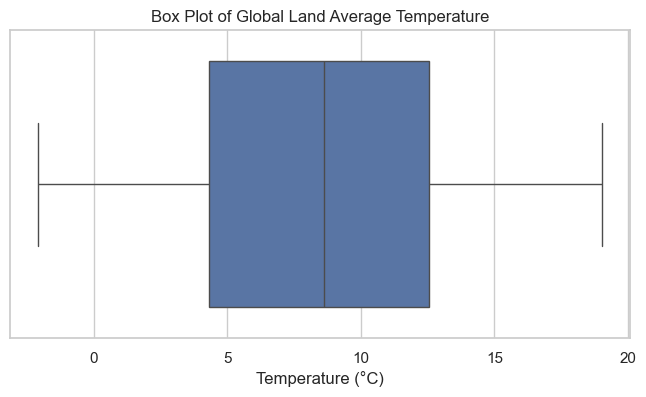

In [6]:
# Outlier CHeck
plt.figure(figsize = (8, 4))
sns.boxplot(x = global_clean["LandAverageTemperature"])
plt.title("Box Plot of Global Land Average Temperature")
plt.xlabel("Temperature (°C)")
plt.show()

This visualization shows the spread of global land average temperatures and highlights values that fall far from the center of the distribution. The distribution appears slightly [skew direction], with a median around ~9–10°C and a range spanning from below 0°C to nearly 20°C, indicating substantial variability over time.

The plot shows [few/no] extreme outliers, suggesting that most values fall within a consistent range rather than being driven by isolated anomalies. This is important because extreme values can influence averages, trend lines, and later comparisons across time periods.

The key insight is that unusual temperature values should be inspected carefully to determine whether they reflect true climate variability or possible data limitations rather than being removed automatically. Additionally, the limited presence of outliers suggests that long-term trends are likely driven by gradual shifts in the overall distribution, supporting more reliable trend analysis.

## Visual Exploration

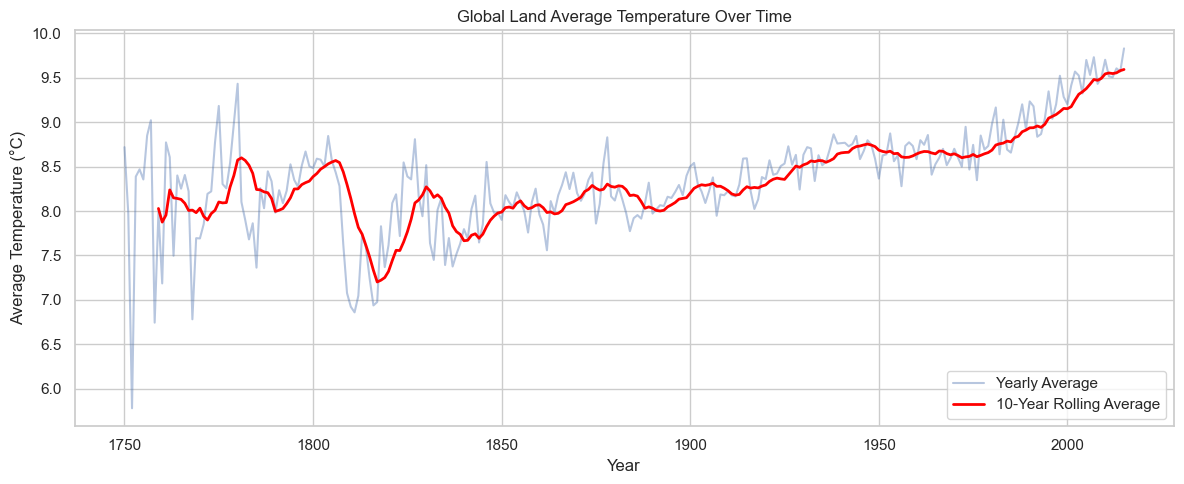

In [7]:
# Line Chart
yearly_global = global_clean.groupby("Year", as_index = False)["LandAverageTemperature"].mean()
yearly_global["RollingAvg"] = yearly_global["LandAverageTemperature"].rolling(window=10).mean()

plt.figure(figsize = (12, 5))

# Raw yearly data (light)
plt.plot(
    yearly_global["Year"],
    yearly_global["LandAverageTemperature"],
    alpha = 0.4,
    label = "Yearly Average"
)

# Smoothed trend (bold)
plt.plot(
    yearly_global["Year"],
    yearly_global["RollingAvg"],
    linewidth = 2,
    color = "red",
    label = "10-Year Rolling Average"
)

plt.title("Global Land Average Temperature Over Time")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")

plt.legend()
plt.tight_layout()
plt.show()

This visualization shows global land average temperature over time, with yearly values in blue and a 10-year rolling average in red to highlight long-term trends. While the yearly data exhibits significant short-term variability, especially in earlier periods, the rolling average smooths these fluctuations and reveals a clear upward trend in temperature.

Temperatures in the 1700s and 1800s appear more volatile, whereas the 20th and 21st centuries show a more consistent increase, indicating a shift in the overall temperature baseline. Notably, the slope of the rolling average becomes steeper after the mid-1900s, suggesting an acceleration in warming.

The key insight is that global temperatures are not only increasing over time but doing so at an increasing rate, supporting evidence of sustained long-term climate change rather than isolated variability.

C:\Users\ninap\AppData\Local\Temp\ipykernel_33352\680300644.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


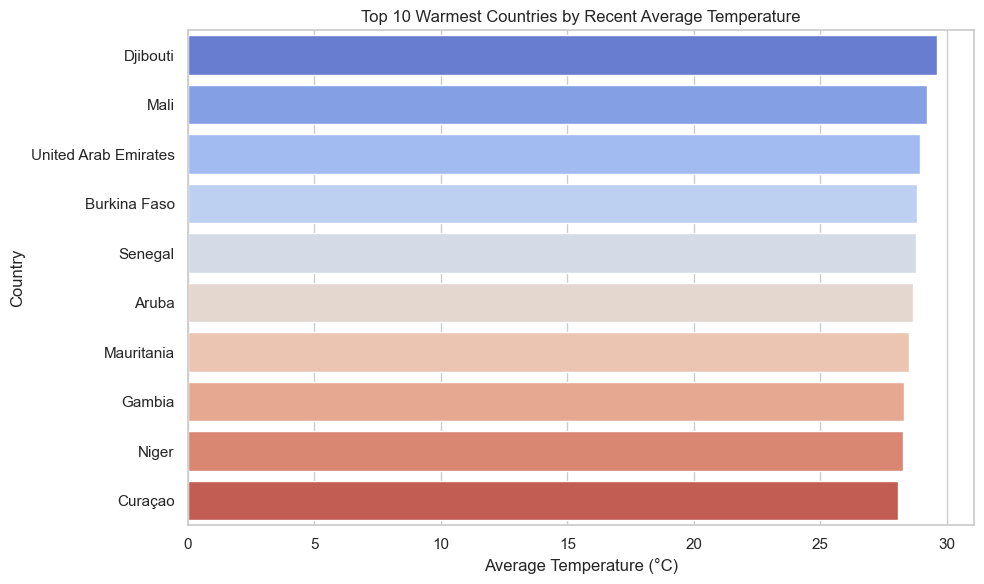

In [8]:
# Bar Chart
recent_countries = country_clean[country_clean["Year"] >= country_clean["Year"].max() - 20]
top_countries = (
    recent_countries.groupby("Country", as_index = False)["AverageTemperature"]
    .mean()
    .sort_values("AverageTemperature", ascending = False)
    .head(10)
)

plt.figure(figsize = (10, 6))

sns.barplot(
    data = top_countries,
    y = "Country",
    x = "AverageTemperature",
    palette = "coolwarm"
)

plt.title("Top 10 Warmest Countries by Recent Average Temperature")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

This visualization highlights the top 10 warmest countries based on recent average temperatures. The results show a clear geographic pattern, with most countries located near the equator, particularly in West Africa and the Middle East. These regions are characterized by high solar exposure and arid or semi-arid climates, which contribute to consistently high temperatures.

The differences in average temperature among these countries are relatively small, indicating that they share similar climate conditions. Countries such as Djibouti, Mali, and the United Arab Emirates all experience persistently high baseline temperatures.

The key insight is that the warmest countries are concentrated in already hot regions, which may make them especially vulnerable to further increases in temperature. This reinforces the importance of considering geographic and regional factors when analyzing global climate trends.

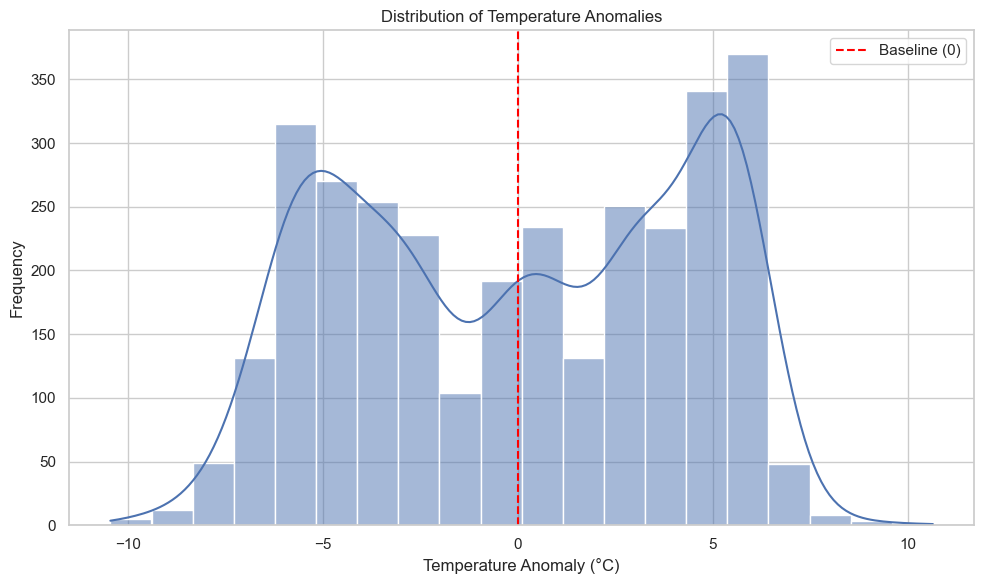

In [9]:
# Histogram
plt.figure(figsize = (10, 6))

sns.histplot(
    global_clean["TemperatureAnomaly"],
    bins=20,
    kde=True
)

plt.axvline(0, color='red', linestyle = '--', label='Baseline (0)')

plt.title("Distribution of Temperature Anomalies")
plt.xlabel("Temperature Anomaly (°C)")
plt.ylabel("Frequency")

plt.legend()
plt.tight_layout()
plt.show()


This histogram shows the distribution of global temperature anomalies, with the red dashed line indicating the baseline of 0°C. The distribution is centered noticeably above zero, indicating that positive temperature anomalies occur more frequently than negative ones.

The shape of the distribution is slightly right-skewed, with a higher concentration of values on the warmer side and a longer tail extending toward higher anomalies. This suggests that extreme warm anomalies occur more often than extreme cold ones.

The key insight is that the overall temperature distribution has shifted upward, meaning that temperatures are more often above the historical baseline than below it. This indicates a systemic warming trend rather than isolated fluctuations.

Additionally, the wide spread of values reflects variability in temperature anomalies, but the dominance of positive values reinforces the long-term warming pattern observed in earlier visualizations.

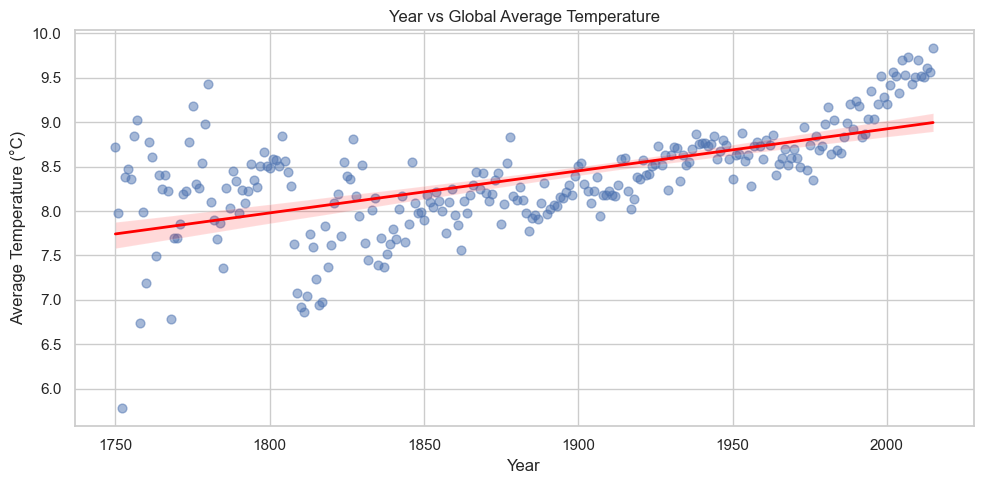

In [10]:
# Scatter Plot
plt.figure(figsize = (10, 5))

sns.regplot(
    data = yearly_global,
    x = "Year",
    y = "LandAverageTemperature",
    scatter_kws = {"alpha": 0.5, "s": 40},
    line_kws = {"color": "red", "linewidth": 2}
)

plt.title("Year vs Global Average Temperature")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")

plt.tight_layout()
plt.show()

This scatter plot illustrates the relationship between year and global average temperature, with a fitted regression line to highlight the overall trend. The data shows a clear positive relationship, indicating that temperatures have generally increased over time.

Although there is noticeable variability in individual years—particularly in earlier periods—the data points largely follow the upward trend represented by the regression line. This suggests that short-term fluctuations are present but do not outweigh the long-term warming pattern.

Additionally, the clustering of points becomes more consistent in recent years, reinforcing the idea of a sustained increase in global temperatures. The regression line also implies that the rate of temperature increase, while gradual, is persistent and cumulative over time. The key insight is that temperature change is not random but follows a clear upward trajectory over time, providing strong evidence of long-term climate warming. 

C:\Users\ninap\AppData\Local\Temp\ipykernel_33352\2923072181.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


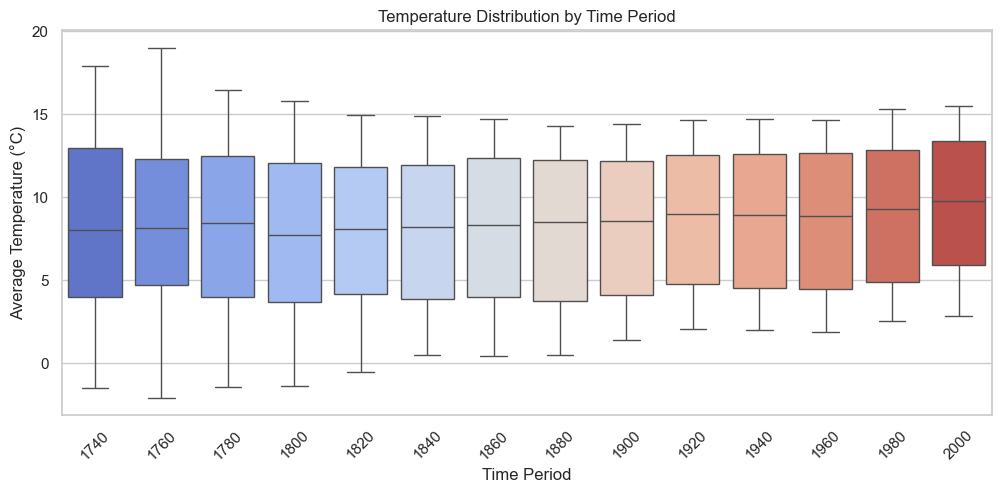

In [11]:
# Box Plot
global_clean["Period"] = (global_clean["Year"] // 20) * 20

plt.figure(figsize = (12, 5))
sns.boxplot(
    data = global_clean,
    x = "Period",
    y = "LandAverageTemperature",
    palette = "coolwarm"
)

plt.title("Temperature Distribution by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Average Temperature (°C)")

plt.xticks(rotation = 45)
plt.show()

This box plot shows the distribution of global average temperatures across different time periods. A clear upward shift in the median values is observed over time, indicating a steady increase in global temperatures.

In addition to rising medians, the entire distribution shifts upward, meaning that both lower and higher temperature values are increasing. Earlier time periods exhibit greater variability and a wider spread of temperatures, while more recent periods show a more concentrated range of higher values.

Notably, extremely low temperatures become less frequent in later periods, suggesting a reduction in colder extremes.

The key insight is that global warming is not limited to increases in average temperature alone but reflects a broader shift in the entire temperature distribution, indicating a fundamental change in climate patterns over time.

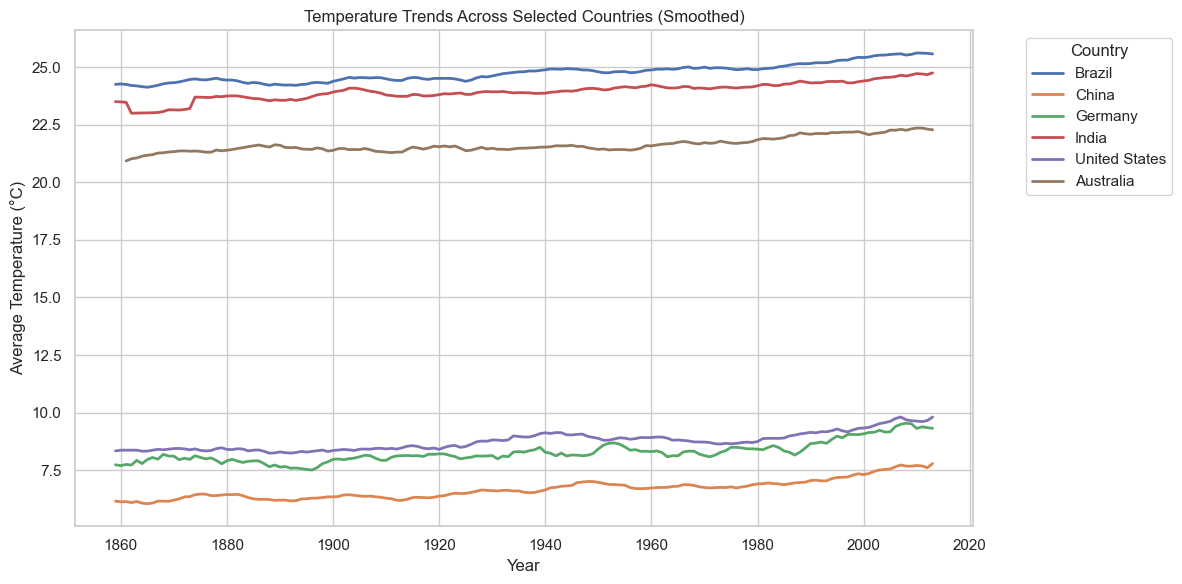

In [12]:
# Multi-Line Chart
selected_countries = [
    "United States",
    "India",
    "China",
    "Brazil",
    "Australia",
    "Germany"
]
multi_df = country_clean[country_clean["Country"].isin(selected_countries)]
multi_year = multi_df.groupby(["Year", "Country"], as_index = False)["AverageTemperature"].mean()

multi_year = multi_year[multi_year["Year"] >= 1850]

multi_year["RollingAvg"] = (
    multi_year.groupby("Country")["AverageTemperature"]
    .transform(lambda x: x.rolling(10).mean())
)

plt.figure(figsize = (12, 6))

sns.lineplot(
    data = multi_year,
    x = "Year",
    y = "RollingAvg",
    hue = "Country",
    linewidth = 2
)

plt.title("Temperature Trends Across Selected Countries (Smoothed)")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")

plt.legend(title = "Country", bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

This visualization shows smoothed temperature trends across selected countries over time. All countries exhibit a clear upward trend, indicating that rising temperatures are a global phenomenon rather than isolated to specific regions.

While the overall pattern is consistent, there are noticeable differences in baseline temperatures. Countries such as Brazil and India maintain higher average temperatures throughout the period, whereas countries like Germany and the United States remain comparatively cooler.

The parallel nature of the trends suggests that warming is occurring simultaneously across different parts of the world, reinforcing the presence of a coordinated global climate shift. Additionally, the use of smoothing highlights long-term patterns by reducing short-term variability.

The key insight is that global warming affects diverse regions similarly in direction, even though absolute temperature levels and rates of increase may vary due to regional climate conditions.

This demonstrates that climate change is not localized, but a widespread and synchronized global process.

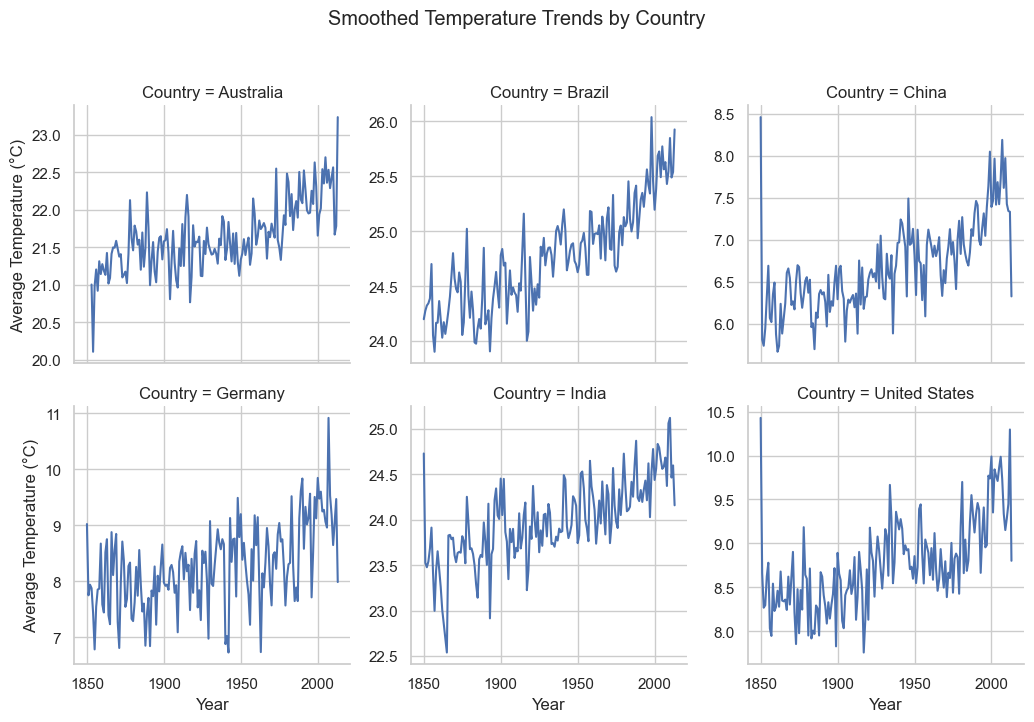

In [13]:
# Faveted / Subplot Visualization
facet_data = country_clean[
    (country_clean["Country"].isin(selected_countries)) &
    (country_clean["Year"] >= 1850)
]
facet_data["RollingAvg"] = (
    facet_data.groupby("Country")["AverageTemperature"]
    .transform(lambda x: x.rolling(10).mean())
)

g = sns.FacetGrid(facet_data, col = "Country", col_wrap = 3, height = 3.5, sharey = False)
g.map_dataframe(sns.lineplot, x = "Year", y = "RollingAvg", errorbar = None)
g.set_axis_labels("Year", "Average Temperature (°C)")
g.fig.suptitle("Smoothed Temperature Trends by Country", y = 1.03)
plt.tight_layout()
plt.show()

This set of plots shows smoothed temperature trends for individual countries over time. Across all countries, there is a clear upward trend in temperature, indicating that warming is a global phenomenon affecting diverse geographic regions.

Although the overall pattern is consistent, there are differences in baseline temperatures and variability. Countries such as Brazil and India maintain higher average temperatures, while Germany and the United States are cooler but still follow the same increasing trend.

Each country also exhibits short-term fluctuations, particularly in earlier periods, but these variations do not override the long-term upward trajectory. In many cases, the increase in temperature becomes more pronounced in recent decades, suggesting accelerated warming.

The key insight is that temperature increases are not isolated to specific regions but are consistently observed across multiple countries, reinforcing the global nature of climate change. This country-level analysis confirms that global warming is both widespread and persistent, regardless of regional climate differences.

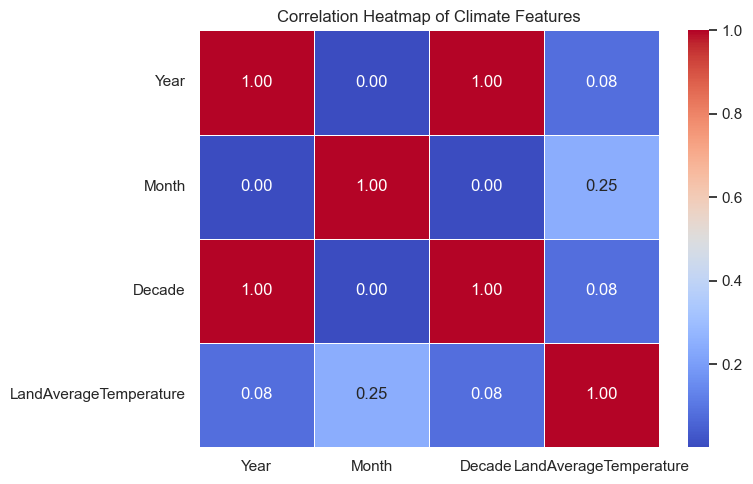

In [14]:
# Heatmap
heatmap_df = global_clean[
    ["Year", "Month", "LandAverageTemperature"]
].corr(numeric_only = True)

global_clean["Decade"] = (global_clean["Year"] // 10) * 10

heatmap_df = global_clean[
    ["Year", "Month", "Decade", "LandAverageTemperature"]
].corr(numeric_only=True)

plt.figure(figsize = (8, 5))

sns.heatmap(
    heatmap_df,
    annot = True,
    cmap = "coolwarm",
    fmt = ".2f",
    linewidths = 0.5
)

plt.title("Correlation Heatmap of Climate Features")
plt.tight_layout()
plt.show()


This heatmap displays the correlation between key climate-related variables. As expected, Year and Decade exhibit a perfect correlation, since Decade is directly derived from Year and does not add independent information.

Land average temperature shows a weak positive correlation with both Year and Decade (~0.08), indicating that while temperatures generally increase over time, the relationship is not strictly linear. Month has a slightly stronger correlation with temperature (~0.25), reflecting the influence of seasonal variation on temperature values.

Overall, most correlations are relatively weak, suggesting that temperature trends are influenced by multiple factors and cannot be fully explained by simple linear relationships with time variables alone.

This supports earlier findings that while long-term warming trends are evident, temperature changes include variability and complexity that extend beyond basic correlations.

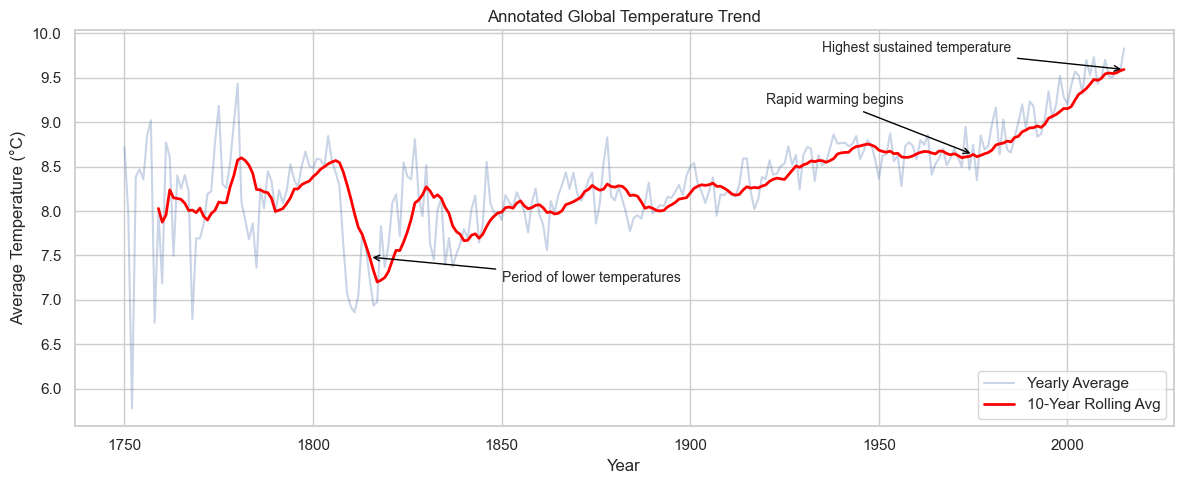

In [15]:
# Annotated Plot
plt.figure(figsize = (12, 5))

# Raw data
plt.plot(
    yearly_global["Year"],
    yearly_global["LandAverageTemperature"],
    alpha = 0.3,
    label = "Yearly Average"
)

# Smoothed trend
plt.plot(
    yearly_global["Year"],
    yearly_global["RollingAvg"],
    color = "red",
    linewidth = 2,
    label = "10-Year Rolling Avg"
)

# Peak point (use smoothed for cleaner result)
max_row = yearly_global.loc[yearly_global["RollingAvg"].idxmax()]

plt.annotate(
    "Highest sustained temperature",
    xy = (max_row["Year"], max_row["RollingAvg"]),
    xytext = (max_row["Year"] - 80, max_row["RollingAvg"] + 0.2),
    arrowprops = dict(arrowstyle = "->", color = "black"),
    fontsize = 10
)

plt.annotate(
    "Rapid warming begins",
    xy = (1975, yearly_global.loc[yearly_global["Year"] == 1975, "RollingAvg"].values[0]),
    xytext = (1920, 9.2),
    arrowprops = dict(arrowstyle = "->", color = "black"),
    fontsize = 10
)

plt.annotate(
    "Period of lower temperatures",
    xy = (1815, yearly_global.loc[yearly_global["Year"] == 1815, "RollingAvg"].values[0]),
    xytext = (1850, 7.2),
    arrowprops = dict(arrowstyle = "->", color = "black"),
    fontsize = 10
)

plt.title("Annotated Global Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")

plt.legend()
plt.tight_layout()
plt.show()

This annotated visualization illustrates the global land temperature trend over time, combining yearly data with a smoothed 10-year rolling average. The overall pattern shows a clear increase in temperature, reinforcing the presence of long-term global warming.

The plot highlights distinct phases in climate behavior, including a period of lower temperatures in the early 1800s, followed by gradual warming and a more rapid increase beginning in the mid-20th century. The slope of the trend becomes steeper after this point, indicating an acceleration in warming.

Notably, the most recent years exhibit the highest sustained temperatures in the dataset, suggesting that warming is ongoing and has not stabilized. While earlier periods display greater variability, these fluctuations are outweighed by the strong and consistent upward trend observed in modern times.

The key insight is that global temperature change is not only increasing but accelerating, with recent decades representing the most significant and sustained warming in the recorded data.

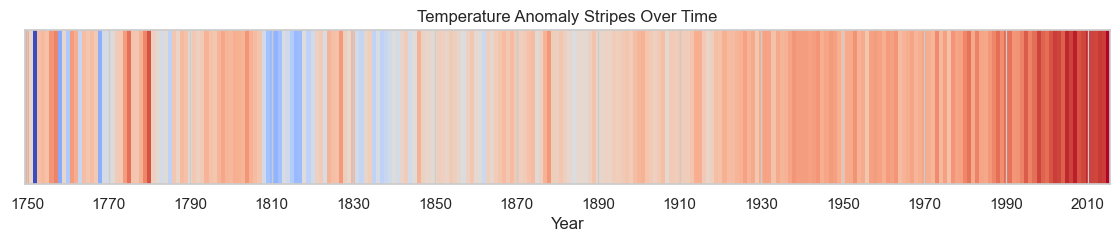

In [16]:
# Custom Visualization
yearly_anomaly = global_clean.groupby("Year", as_index = False)["TemperatureAnomaly"].mean()

stripe_data = yearly_anomaly["TemperatureAnomaly"].values.reshape(1, -1)

plt.figure(figsize = (14, 2))
plt.imshow(stripe_data, aspect = "auto", cmap = "coolwarm")
plt.yticks([])
plt.xticks(
    ticks = range(0, len(yearly_anomaly), 20),
    labels = yearly_anomaly["Year"].iloc[::20]
)
plt.title("Temperature Anomaly Stripes Over Time")
plt.xlabel("Year")
plt.show()

This visualization displays temperature anomaly “stripes” over time, where blue represents cooler-than-average years and red represents warmer-than-average years. A clear transition from predominantly blue tones in earlier years to deep red tones in recent decades is observed.

Early periods show a mix of cooler and warmer anomalies, indicating greater variability. However, beginning in the mid-20th century, the stripes become increasingly dominated by red hues, reflecting a consistent pattern of above-average temperatures.

The near absence of blue stripes in recent years suggests that cooler-than-average conditions have become rare.

The key insight is that global temperatures have shifted significantly over time, with recent decades characterized by sustained and widespread warming, reinforcing the long-term climate change trend.

In [17]:
# Interactive Visualization
pio.renderers.default = "browser"

global_yearly = (
    global_clean.groupby("Year", as_index = False)["LandAverageTemperature"]
    .mean()
    .rename(columns = {"LandAverageTemperature": "GlobalAverageTemperature"})
)


country_yearly = (
    country_clean.groupby(["Year", "Country"], as_index = False)["AverageTemperature"]
    .mean()
)

# Limit to more complete modern-era data for cleaner interaction
global_yearly = global_yearly[global_yearly["Year"] >= 1850]
country_yearly = country_yearly[country_yearly["Year"] >= 1850]

# Countries to include in dropdown
interactive_countries = [
    "United States",
    "India",
    "China",
    "Brazil",
    "Australia",
    "Germany"
]

fig = go.Figure()

# Add global trace
fig.add_trace(
    go.Scatter(
        x = global_yearly["Year"],
        y = global_yearly["GlobalAverageTemperature"],
        mode = "lines",
        name = "Global Average",
        line = dict(width = 2, color = "blue"),
        visible = True
    )
)

# Add one country at a time
for i, country in enumerate(interactive_countries):
    country_data = country_yearly[country_yearly["Country"] == country]

    fig.add_trace(
        go.Scatter(
            x = country_data["Year"],
            y = country_data["AverageTemperature"],
            mode = "lines",
            name = country,
            visible = True if i == 0 else False
        )
    )

# Dropdown buttons
buttons = []
for i, country in enumerate(interactive_countries):
    visible = [True] + [False] * len(interactive_countries)
    visible[i + 1] = True

    buttons.append(
        dict(
            label = country,
            method = "update",
            args = [
                {"visible": visible},
                {
                    "title": f"{country} vs Global Average Temperature Over Time",
                    "yaxis": {"title": "Average Temperature (°C)"},
                    "xaxis": {"title": "Year"}
                }
            ]
        )
    )

fig.update_layout(
    title = f"{interactive_countries[0]} vs Global Average Temperature Over Time",
    xaxis_title = "Year",
    yaxis_title = "Average Temperature (°C)",
    template = "plotly_white",
    hovermode = "x unified",
    updatemenus = [
        dict(
            buttons = buttons,
            direction = "down",
            showactive = True,
            x = 1.02,
            y = 1.15
        )
    ]
)

fig.show()

This interactive visualization compares temperature trends between the global average and a selected country over time. Across different country selections, several consistent patterns can be observed.

First, both the global average and individual country temperatures generally follow an upward trend, indicating that warming is occurring at both global and regional levels. While the global trend appears smoother, individual countries often show greater short-term variability, reflecting regional climate fluctuations.

Additionally, although countries differ in their baseline temperatures, their trends tend to move in the same direction as the global average. This suggests that temperature changes are not isolated but part of a broader global pattern.

In some cases, certain countries may warm slightly faster or exhibit more pronounced fluctuations, highlighting regional differences in climate behavior.

The key insight is that while the magnitude and variability of temperature changes vary by country, the overall direction of change remains consistent, reinforcing the global nature of climate warming.

In [21]:
# Interactive Plot 2
pio.renderers.default = "browser"

# Keep cleaner modern-era data
country_period = country_clean[country_clean["Year"] >= 1850].copy()

# Define comparison periods
periods = {
    "1900 vs 2000": (1900, 1910, 2000, 2010),
    "1950 vs 2000": (1950, 1960, 2000, 2010),
    "1970 vs 2000": (1970, 1980, 2000, 2010),
    "1980 vs 2010": (1980, 1990, 2010, 2020)
}

# Build warming data for each period
warming_maps = {}
   
for label, (start1, end1, start2, end2) in periods.items():
    early = (
        country_period[(country_period["Year"] >= start1) & (country_period["Year"] < end1)]
        .groupby("Country", as_index = False)["AverageTemperature"]
        .mean()
        .rename(columns = {"AverageTemperature": "EarlyAvg"})
    )
    
    late = (
        country_period[(country_period["Year"] >= start2) & (country_period["Year"] < end2)]
        .groupby("Country", as_index = False)["AverageTemperature"]
        .mean()
        .rename(columns = {"AverageTemperature": "LateAvg"})
    )
    
    merged = early.merge(late, on = "Country", how = "inner")
    merged["TemperatureChange"] = merged["LateAvg"] - merged["EarlyAvg"]
    warming_maps[label] = merged

# Create figure
fig = go.Figure()

period_labels = list(periods.keys())

# Add one choropleth per period
for i, label in enumerate(period_labels):
    df = warming_maps[label]
    
    fig.add_trace(
        go.Choropleth(
            locations = df["Country"],
            locationmode = "country names",
            colorscale = "Plasma",
            reversescale = True,
            zmax = 3,
            zmin = 0,
            z = df["TemperatureChange"],
            text = df["Country"],
            colorbar_title = "Δ Temp (°C)",
            hovertemplate = (
                "<b>%{text}</b><br>" +
                "Temperature Change: %{z:.2f}°C<br>" +
                "<extra></extra>"
            ),
            visible = True if i == 0 else False
        )
    )

# Dropdown menu
buttons = []
for i, label in enumerate(period_labels):
    visible = [False] * len(period_labels)
    visible[i] = True
    
    buttons.append(
        dict(
            label = label,
            method = "update",
            args = [
                {"visible": visible},
                {"title": f"Country-Level Temperature Change: {label}"}
            ]
        )
    )

fig.update_layout(
    title = f"Country-Level Temperature Change: {period_labels[0]}",
    geo = dict(showframe = False, showcoastlines = True, projection_type = "equirectangular"),
    template = "plotly_white",
    updatemenus = [
        dict(
            buttons = buttons,
            direction = "down",
            showactive = True,
            x = 1.02,
            y = 1.15
        )
    ]
)

fig.show()

This interactive visualization shows how average temperatures have changed across countries over different selected time periods. By allowing users to switch between time ranges, the plot highlights how warming patterns vary both geographically and historically.

First, across all time period selections, most countries display positive temperature changes, indicating that warming is widespread rather than isolated to specific regions. This reinforces the overall global trend of increasing temperatures observed in earlier visualizations.

Additionally, the map reveals clear geographic patterns. Certain regions, particularly in higher latitudes, tend to exhibit stronger temperature increases compared to others. This suggests that climate change does not affect all areas equally, and some regions are more sensitive to warming.

Another noticeable pattern is that more recent time periods often show larger temperature increases compared to earlier ones. This indicates that warming has accelerated over time, with more pronounced changes occurring in the late 20th and early 21st centuries.

The visualization also highlights variation between countries, where some experience more moderate changes while others show more extreme increases. These differences may reflect regional climate conditions, geography, or environmental factors.

The key insight is that while global warming is a shared trend across countries, its intensity varies by location and time period, demonstrating that climate change is both a global and regionally uneven phenomenon.